#  ACE2-RBD Model Analysis & Plotting Notebook

- Loading the saved ACE2-RBD model and generate all evaluation related plots 
- Analyze model performance in detail for random test set

**Required files:**
- Saved model (`.pt` file)
- Preprocessed data (`embeddings.npz`)
- Pipeline modules (config.py, model.py)

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import json
import warnings
from pathlib import Path
from data_utils import ACE2RBDDataset, collate_batch
from torch.utils.data import DataLoader

import torch
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, r2_score, mean_squared_error
)
from sklearn.preprocessing import label_binarize
from scipy.stats import pearsonr

from config import Config
from model import ACE2RBDBindingModel
from data_utils import DataSplitter, create_data_loaders, load_preprocessed_data
from utils import get_device, set_seed

warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.5.1+cu121
CUDA available: True


## Configuration

In [2]:
# =============================================================================
# Path and Configuration Settings
# =============================================================================
MODEL_PATH = "./outputs/models/combined_model.pt"
DATA_PATH = "Embeddings/embeddings.npz"
PLOTS_DIR = "./notebook_plots"

# Class names
CLASS_NAMES = ["Strong", "Medium", "Weak", "No Bind"]


Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)
device = get_device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

print(f"Model  : {MODEL_PATH}")
print(f"Data   : {DATA_PATH}")
print(f"Plots  : {PLOTS_DIR}")
print(f"Device : {device}")

Using GPU: NVIDIA GeForce RTX 3070
GPU Memory: 8.59 GB
Model  : ./outputs/models/combined_model.pt
Data   : Embeddings/embeddings.npz
Plots  : ./notebook_plots
Device : cuda


In [3]:
from pathlib import Path

model_path = Path(MODEL_PATH).expanduser().resolve()
data_path  = Path(DATA_PATH).expanduser().resolve()


## Load Data and Model

In [4]:
print("Loading preprocessed data...")
data = load_preprocessed_data(DATA_PATH)

print(f"\n Loading saved model...")
combined   = torch.load(MODEL_PATH, map_location=device)
checkpoint = combined["best_eval_model"]
print(f"  Model loaded from : {MODEL_PATH}")

Loading preprocessed data...
  Available fields: ['rbd_embeddings', 'ace2_embeddings', 'rbd_masks', 'ace2_masks', 'pkd_values', 'class_ids', 'sample_ids', 'rbd_sequences', 'ace2_sequences', 'norm_rbd_mean', 'norm_rbd_std', 'norm_ace2_mean', 'norm_ace2_std']

 Loading saved model...
  Model loaded from : ./outputs/models/combined_model.pt


In [ ]:

from config import Config
from sklearn.model_selection import train_test_split
cfg = Config.from_yaml("config.yaml")
all_idx = np.arange(len(data["class_ids"]))

_, test_idx = train_test_split(
    all_idx,
    test_size=0.10,
    stratify=data["class_ids"],
    random_state=42
)

test_loader = DataLoader(
    ACE2RBDDataset(data, test_idx),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_batch,
)

In [24]:
#Build model and load weights
cfg = checkpoint.get('model_config', {
    'embedding_dim': data['rbd_embeddings'].shape[-1],
    'num_classes':   4,
    'dropout':       0.15,
    'drop_path':     0.15,
    'num_heads':     12,
})

model = ACE2RBDBindingModel(
    embedding_dim = cfg['embedding_dim'],
    num_classes   = cfg['num_classes'],
    dropout       = cfg.get('dropout',   0.15),
    drop_path     = cfg.get('drop_path', 0.15),
    num_heads     = cfg.get('num_heads', 12),
).to(device)

model.load_state_dict(checkpoint['state_dict'])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded — {n_params:,} parameters")

Model loaded — 21,382,085 parameters


## Model Evaluation & Data Generation

In [25]:
def run_evaluation(model, dataloader, device):
    """Run model inference and collect all predictions."""
    model.eval()
    y_true_reg, y_pred_reg = [], []
    y_true_cls, y_pred_cls = [], []
    y_pred_probs = []

    with torch.no_grad():
        for batch in dataloader:
            x1, x2, m1, m2, reg_labels, cls_labels = batch
            x1, x2, m1, m2 = x1.to(device), x2.to(device), m1.to(device), m2.to(device)

            reg_out, cls_out = model(x1, x2, m1, m2)
            probs = torch.softmax(cls_out, dim=1)

            y_true_reg.append(reg_labels.cpu().numpy())
            y_pred_reg.append(reg_out.cpu().numpy())
            y_true_cls.append(cls_labels.cpu().numpy())
            y_pred_cls.append(cls_out.argmax(dim=1).cpu().numpy())
            y_pred_probs.append(probs.cpu().numpy())

    return {
        'y_true_reg':   np.concatenate(y_true_reg).ravel(),
        'y_pred_reg':   np.concatenate(y_pred_reg).ravel(),
        'y_true_cls':   np.concatenate(y_true_cls),
        'y_pred_cls':   np.concatenate(y_pred_cls),
        'y_pred_probs': np.concatenate(y_pred_probs),
    }

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score,balanced_accuracy_score
outputs = run_evaluation(model, test_loader, device)

y_true_reg = outputs['y_true_reg']
y_pred_reg = outputs['y_pred_reg']
y_true_cls = outputs['y_true_cls']
y_pred_cls = outputs['y_pred_cls']
y_pred_probs = outputs['y_pred_probs']


## 1. Confusion Matrix

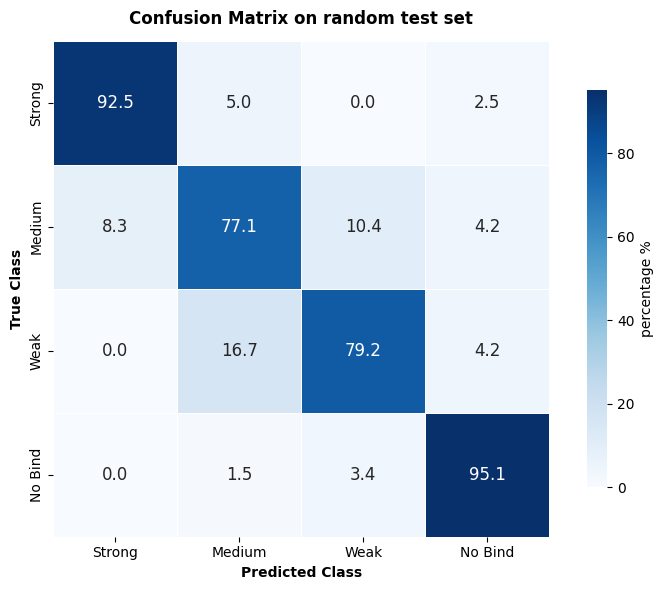

In [27]:
cm = confusion_matrix(y_true_cls, y_pred_cls)
row_sums = cm.sum(axis=1, keepdims=True)
cm_pct = np.divide(cm, row_sums,
                   out=np.zeros_like(cm, dtype=float),
                   where=row_sums != 0) * 100

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_pct, annot=True, fmt=".1f",
    annot_kws={"size": 12},
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="Blues", square=True, linewidths=0.5,
    cbar_kws={"label": "percentage %", "shrink": 0.8},
    ax=ax
)

ax.set_title(f"Confusion Matrix on random test set",
             fontweight="bold", pad=12)
ax.set_xlabel("Predicted Class", fontweight="bold")
ax.set_ylabel("True Class",      fontweight="bold")

plt.tight_layout()
plt.savefig(Path(PLOTS_DIR) / "confusion_matrix.png",          dpi=200, bbox_inches="tight")
plt.show()

## 2. Regression Scatter Plot (True vs Predicted)

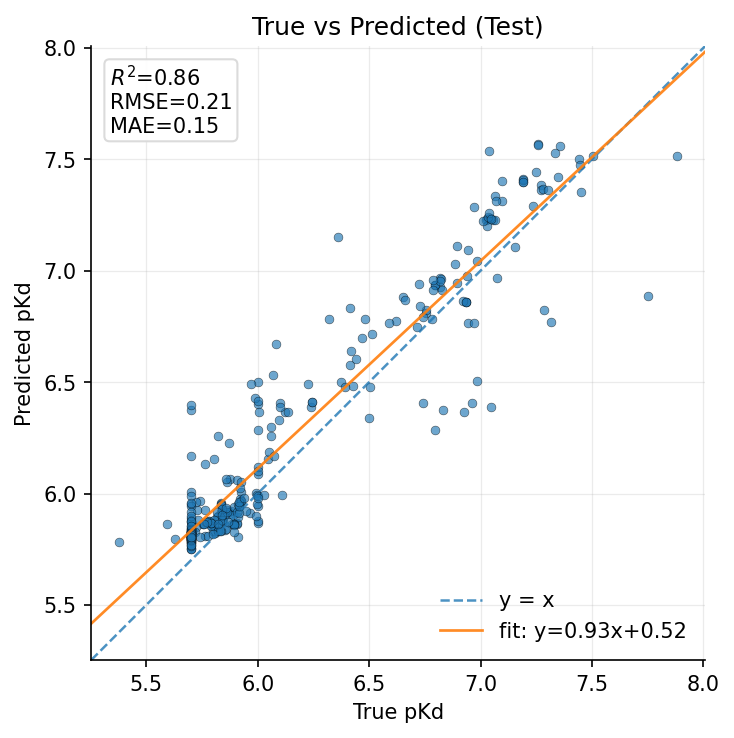

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_true = np.asarray(outputs["y_true_reg"]).ravel()
y_pred = np.asarray(outputs["y_pred_reg"]).ravel()

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = np.mean(np.abs(y_true - y_pred))

fig, ax = plt.subplots(figsize=(5, 6), dpi=150)

vmin = float(min(y_true.min(), y_pred.min()))
vmax = float(max(y_true.max(), y_pred.max()))
pad = 0.05 * (vmax - vmin + 1e-9)
lo, hi = vmin - pad, vmax + pad

ax.scatter(
    y_true, y_pred,
    s=18, alpha=0.65,
    edgecolors="black", linewidth=0.25
)

ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2, alpha=0.8, label="y = x")

m, b = np.polyfit(y_true, y_pred, 1)
xline = np.array([lo, hi])
ax.plot(xline, m * xline + b, linewidth=1.3, alpha=0.9, label=f"fit: y={m:.2f}x+{b:.2f}")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("True pKd")
ax.set_ylabel("Predicted pKd")
ax.set_title("True vs Predicted (Test)")

ax.grid(True, linewidth=0.6, alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.03, 0.97,
    f"$R^2$={r2:.2f}\nRMSE={rmse:.2f}\nMAE={mae:.2f}",
    transform=ax.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.95)
)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(Path(PLOTS_DIR) / "True_vs_predicted.png",          dpi=200, bbox_inches="tight")
plt.show()


### 3. Residual Plot

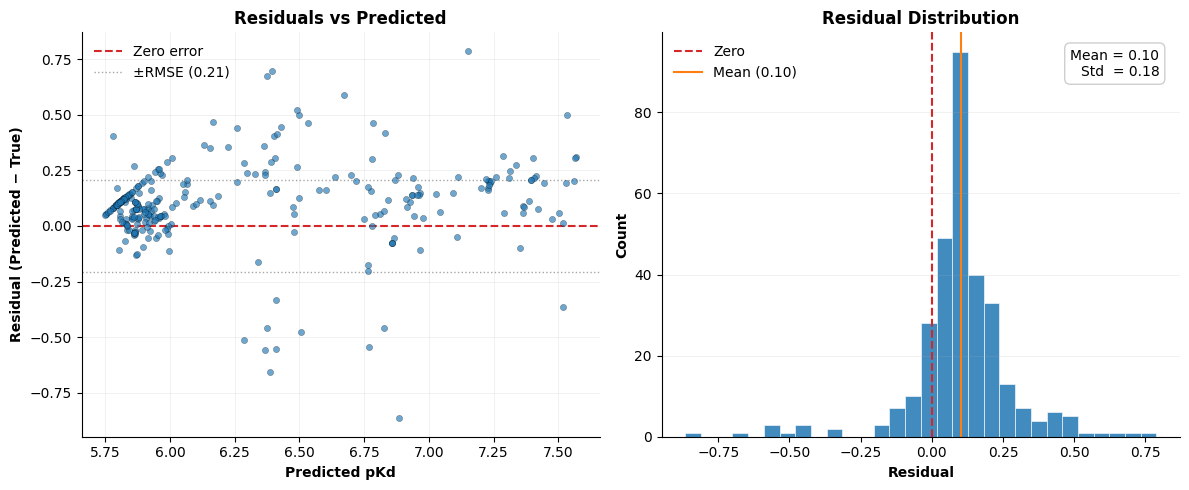

In [30]:
residuals = y_pred_reg - y_true_reg

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#residuals vs predicted
ax = axes[0]
ax.scatter(y_pred_reg, residuals,
           s=20, alpha=0.65, edgecolors="black", linewidth=0.25, zorder=3)
ax.axhline(0, color="#d62728", linewidth=1.5, linestyle="--", label="Zero error")

# ±1 RMSE band
ax.axhline( rmse, color="gray", linewidth=1, linestyle=":", alpha=0.7, label=f"±RMSE ({rmse:.2f})")
ax.axhline(-rmse, color="gray", linewidth=1, linestyle=":", alpha=0.7)

ax.set_xlabel("Predicted pKd", fontweight="bold")
ax.set_ylabel("Residual (Predicted − True)", fontweight="bold")
ax.set_title("Residuals vs Predicted", fontweight="bold")
ax.grid(True, lw=0.5, alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10, frameon=False)

# residual distribution
ax = axes[1]
ax.hist(residuals, bins=30, edgecolor="white", linewidth=0.5, color="#1f77b4", alpha=0.85)
ax.axvline(0,            color="#d62728", linewidth=1.5, linestyle="--", label="Zero")
ax.axvline(residuals.mean(), color="#ff7f0e", linewidth=1.5, linestyle="-",
           label=f"Mean ({residuals.mean():.2f})")

ax.set_xlabel("Residual", fontweight="bold")
ax.set_ylabel("Count",    fontweight="bold")
ax.set_title("Residual Distribution", fontweight="bold")
ax.grid(True, lw=0.5, alpha=0.25, axis="y")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10, frameon=False)

ax.text(0.96, 0.96,
        f"Mean = {residuals.mean():.2f}\nStd  = {residuals.std():.2f}",
        transform=ax.transAxes, va="top", ha="right", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="0.8", alpha=0.95))

plt.tight_layout()
plt.savefig(Path(PLOTS_DIR) / "residual_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

In [31]:
#Calculate all metrics and save summary
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score
 
# Calculate regression metrics
r2   = r2_score(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
mae  = np.mean(np.abs(y_true_reg - y_pred_reg))
pearson_r, pearson_p = pearsonr(y_true_reg, y_pred_reg)
 
# Calculate classification metrics
accuracy = (y_true_cls == y_pred_cls).mean()
macro_accuracy = balanced_accuracy_score(y_true_cls, y_pred_cls)
precision_macro  = precision_score(y_true_cls, y_pred_cls, average="macro")
recall_macro     = recall_score(y_true_cls, y_pred_cls, average="macro")
f1_macro         = f1_score(y_true_cls, y_pred_cls, average="macro")
 
precision_weighted = precision_score(y_true_cls, y_pred_cls, average="weighted")
recall_weighted    = recall_score(y_true_cls, y_pred_cls, average="weighted")
f1_weighted        = f1_score(y_true_cls, y_pred_cls, average="weighted")
 
 
# --- Save JSON ---
summary = {
    "model_path":  MODEL_PATH,
    "split":       "random_test_split",
    "test_size":   0.15,
    "random_seed": 42,
    "regression": {
        "r2":        round(float(r2), 4),
        "rmse":      round(float(rmse), 4),
        "mae":       round(float(mae), 4),
        "pearson_r": round(float(pearson_r), 4),
    },
    "classification": {
        "accuracy":           round(float(accuracy), 4),
        "weighted_accuracy":  round(float(macro_accuracy), 4),
        "weighted_precision": round(float(precision_macro), 4),
        "weighted_recall":    round(float(recall_macro), 4),
        "weighted_f1":        round(float(f1_macro), 4),
    },
    "plots_saved_to": str(PLOTS_DIR),
}
 
summary_path = Path(PLOTS_DIR) / "metrics_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
 
print(f"Summary saved → {summary_path}")

Summary saved → notebook_plots\metrics_summary.json
